In [10]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [11]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int
    strike_rate:float
    boundariesperball:float
    boundaryPercentage:float
    summary:str

In [12]:
def strike_rate(state:BatsmanState):
  
  sr = (state['runs']/state['balls'])*100
  state['strike_rate'] = sr

  return {'strike_rate': sr}

In [13]:
def boundariesperball(state:BatsmanState):
  
  bpb = (state['fours'] + state['sixes'])/state['balls']
  state['boundariesperball'] = bpb
 

  return {'boundariesperball': bpb}
    

In [14]:
def boundaryPercentage(state : BatsmanState):
  
  bpers = (state['fours'] * 4 + state['sixes'] * 6) / state['runs'] * 100
  state['boundaryPercentage'] = bpers
  return {'boundaryPercentage': bpers}

In [15]:
def summary(state : BatsmanState):
  
  summary = f"""
  Strike Rate = {state['strike_rate']} \n
  Boundaries Per Ball = {state['boundariesperball']} \n
  Boundary Percentage = {state['boundaryPercentage']} \n
  """
  state['summary'] = summary
  return {'summary': summary}

In [16]:
graph = StateGraph(BatsmanState)

graph.add_node('strike_rate' , strike_rate)
graph.add_node('boundariesperball' , boundariesperball)
graph.add_node('boundaryPercentage' , boundaryPercentage)
graph.add_node('summary' , summary)

graph.add_edge(START , 'strike_rate')
graph.add_edge(START , 'boundariesperball')
graph.add_edge(START , 'boundaryPercentage')

graph.add_edge('strike_rate' , 'summary')
graph.add_edge('boundariesperball' , 'summary')
graph.add_edge('boundaryPercentage' , 'summary')

graph.add_edge('summary' , END)


workflow = graph.compile()

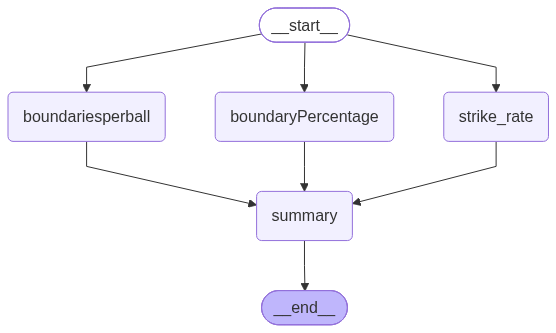

In [17]:
from IPython.display import Image, display


display(
    Image(
        workflow.get_graph().draw_mermaid_png()
    )
)

In [18]:

initial_state = {
    'runs': 100,
    'balls': 60,
    'fours': 10,
    'sixes': 5,
    'strike_rate': 0.0,
    'boundariesperball': 0.0,
    'boundaryPercentage': 0.0,
    'summary': ''
}

workflow.invoke(initial_state)



{'runs': 100,
 'balls': 60,
 'fours': 10,
 'sixes': 5,
 'strike_rate': 166.66666666666669,
 'boundariesperball': 0.25,
 'boundaryPercentage': 70.0,
 'summary': '\n  Strike Rate = 166.66666666666669 \n\n  Boundaries Per Ball = 0.25 \n\n  Boundary Percentage = 70.0 \n\n  '}